# Lab 4: De la RNN al Transformer — una evolución visual


---

> *"I went to the **bank** to withdraw money."*
>
> *"I sat on the **bank** of the river."*

La misma palabra. Dos significados opuestos. ¿Puede una máquina distinguirlos?

Esa pregunta guía todo el lab. Recorremos cuatro arquitecturas y medimos, en cada una, si son capaces de separar los dos *bank* — hasta llegar a BERT, que sí lo consigue.

---

| Bloque | Arquitectura | Pregunta clave |
|:------:|:-------------|:---------------|
| 1 | RNN | ¿Puede "recordar" el contexto al procesar *bank*? |
| 2 | Atención | ¿Y si cada token pudiera ver a todos los demás? |
| 3 | Transformer | ¿Cómo escalar la atención a millones de parámetros? |
| 4 | BERT / GPT | ¿Qué ganamos con los modelos pre-entrenados? |


In [1]:
import os, time, warnings
warnings.filterwarnings("ignore")
os.environ["USE_TF"] = "0"

from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

from transformers import (
    BertTokenizer, BertModel,
    GPT2Tokenizer, GPT2LMHeadModel,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_theme(style="whitegrid", font_scale=1.05)

VOCAB  = {"the": 0, "bank": 1, "is": 2, "closed": 3, "by": 4, "river": 5}
FRASE1 = ["the", "bank", "is", "closed"]
FRASE2 = ["the", "bank", "by", "the", "river"]

def frase_a_tensor(frase, vocab):
    idx = torch.tensor([vocab[w] for w in frase])
    return F.one_hot(idx, num_classes=len(vocab)).float().unsqueeze(1)

def estados_por_paso(frase, vocab, modelo):
    estados, h = [], None
    for token in frase:
        x = frase_a_tensor([token], vocab)
        with torch.no_grad():
            _, h = modelo(x, h)
        estados.append(h.squeeze().numpy().copy())
    return np.array(estados)

class TransformerEncoderMinimo(nn.Module):
    def __init__(self, d_model=16, n_heads=2, d_ff=32):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.ff    = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        a, pw = self.attn(x, x, x)
        x = self.norm1(x + a)
        x = self.norm2(x + self.ff(x))
        return x, pw

def coseno(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def plot_rnn_estados(e1, e2, idx_bank=1):
    fig, ax = plt.subplots(figsize=(8, 2))
    data = np.array([e1[idx_bank], e2[idx_bank]])
    sns.heatmap(data, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                xticklabels=[f"h{i}" for i in range(data.shape[1])],
                yticklabels=['"is closed"', '"by river"'],
                annot=True, fmt=".2f", annot_kws={"size": 9},
                cbar_kws={"label": "valor"})
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va="center")
    ax.set_title("Estado oculto de \'bank\' en cada frase — RNN", fontsize=12)
    ax.set_xlabel("Unidades del estado oculto")
    plt.tight_layout(); plt.show()

def plot_atencion(pesos_np, attn_tokens):
    n = len(attn_tokens)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.heatmap(pesos_np, ax=axes[0], cmap="Blues", vmin=0, vmax=1,
                annot=True, fmt=".2f",
                xticklabels=attn_tokens, yticklabels=attn_tokens,
                linewidths=0.5, cbar_kws={"label": "Peso de atención"})
    axes[0].set_title("Pesos de atención\n(fila = quién atiende, col = a quién atiende)", fontsize=11)
    axes[0].set_xlabel("Token atendido"); axes[0].set_ylabel("Token que atiende")
    idx_bank = attn_tokens.index("bank")
    wedges, texts, autotexts = axes[1].pie(
        pesos_np[idx_bank], labels=attn_tokens, autopct="%.1f%%", startangle=90,
        colors=sns.color_palette("Blues_d", n),
        wedgeprops={"edgecolor": "white", "linewidth": 1.5})
    for at in autotexts: at.set_fontsize(11)
    axes[1].set_title('¿A qué atiende "bank"?\n(pesos aleatorios, sin entrenar)', fontsize=11)
    fig.suptitle("Mecanismo de Atención", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

def plot_transformer(rnn_p, total_params, pesos_enc):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    modelos   = ["RNN\n(h=4)", "Encoder\nMínimo", "BERT\nbase", "GPT-3"]
    n_params  = [rnn_p, total_params, 110_000_000, 175_000_000_000]
    colores_p = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
    bars = axes[0].bar(modelos, n_params, color=colores_p, edgecolor="white")
    axes[0].set_yscale("log"); axes[0].set_ylim(1, 5e13)
    axes[0].set_ylabel("Número de parámetros (escala log)")
    axes[0].set_title("Escala de complejidad de los modelos")
    for bar, p in zip(bars, n_params):
        label = (str(p) if p < 1_000 else
                 f"{p/1e3:.0f}K" if p < 1e6 else
                 f"{p/1e6:.0f}M" if p < 1e9 else f"{p/1e9:.0f}B")
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 2,
                     label, ha="center", va="bottom", fontsize=9, fontweight="bold")
    pw_np = pesos_enc.detach().squeeze(0).numpy()
    n = pw_np.shape[0]
    sns.heatmap(pw_np, ax=axes[1], cmap="Blues", vmin=0, vmax=1,
                annot=True, fmt=".2f",
                xticklabels=[f"t{i}" for i in range(n)],
                yticklabels=[f"t{i}" for i in range(n)], linewidths=0.5)
    axes[1].set_title("Atención del encoder\n(tokens aleatorios, sin entrenar)")
    axes[1].set_xlabel("Token atendido"); axes[1].set_ylabel("Token que atiende")
    plt.tight_layout(); plt.show()

def plot_bert_pca(todos_embs, todas_labels, todos_grupos, sim):
    coords = PCA(n_components=2).fit_transform(np.array(todos_embs))
    paleta = {0: "#C44E52", 1: "#4C72B0", 2: "#55A868"}
    marker = {0: "*",      1: "*",       2: "o"}
    size   = {0: 350,      1: 350,       2: 150}
    fig, ax = plt.subplots(figsize=(9, 6))
    for i, (label, grupo) in enumerate(zip(todas_labels, todos_grupos)):
        ax.scatter(coords[i, 0], coords[i, 1],
                   color=paleta[grupo], marker=marker[grupo],
                   s=size[grupo], zorder=5, edgecolors="white", linewidths=0.5)
        ax.annotate("  " + label.replace("\n", " "),
                    (coords[i, 0], coords[i, 1]), fontsize=10, va="center",
                    color=paleta[grupo])
    ax.legend(handles=[
        Line2D([0],[0], marker="*", color="w", markerfacecolor="#C44E52",
               ms=14, label=f"bank (finanzas)  sim={sim:.2f}"),
        Line2D([0],[0], marker="*", color="w", markerfacecolor="#4C72B0",
               ms=14, label="bank (río)"),
        Line2D([0],[0], marker="o", color="w", markerfacecolor="#55A868",
               ms=10, label="otras palabras"),
    ], loc="best", fontsize=10)
    ax.set_title("BERT: embeddings contextuales (PCA 2D)\n"
                 "Las dos ★ \'bank\' están en posiciones distintas del espacio semántico",
                 fontsize=11)
    ax.set_xlabel("Componente 1"); ax.set_ylabel("Componente 2")
    ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

def plot_comparacion_attn_contextos(pesos1, pesos2, tokens1, tokens2):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, pesos, tokens, titulo in [
        (axes[0], pesos1, tokens1, '\"bank\" en contexto: \"...is closed\"'),
        (axes[1], pesos2, tokens2, '\"bank\" en contexto: \"...by river\"'),
    ]:
        idx_b = tokens.index("bank")
        row   = pesos[idx_b]
        bars  = ax.bar(tokens, row,
                       color=sns.color_palette("Blues_d", len(tokens)),
                       edgecolor="white")
        for bar, v in zip(bars, row):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                    f"{v:.2f}", ha="center", fontsize=10)
        ax.set_title(titulo, fontsize=11)
        ax.set_ylabel("Peso de atención desde \'bank\'" if ax is axes[0] else "")
        ax.set_ylim(0, 1.15)
    fig.suptitle(
        "La atención redistribuye los pesos según el contexto completo\n"
        "Incluso sin entrenar, los pesos son distintos en cada contexto",
        fontsize=11, y=1.03)
    plt.tight_layout(); plt.show()

print("✅ Todo listo")


✅ Todo listo


---
## 🔁 Bloque 1 — Red Neuronal Recurrente (RNN)

Una RNN lee el texto **de izquierda a derecha**, un token a la vez.
En cada paso actualiza un **estado oculto** (un pequeño vector numérico) que resume lo que ha leído hasta ahora.

**¿Qué problema tiene?** El estado oculto es un vector de tamaño fijo. Si la frase es muy larga, la información del principio se "diluye" o desaparece.

<div style="background:#fff9c4; border-left:4px solid #f9a825; padding:12px 16px; border-radius:6px; margin:6px 0">

**🤔 Pausa y predice — RNN**

Vamos a visualizar el estado oculto de la RNN token a token en dos frases donde *"banco"* tiene significados distintos.

¿Crees que la representación de *"banco"* será diferente en las dos frases?

<details><summary>💡 Ver respuesta</summary>

**No, será idéntica.** La RNN es unidireccional: cuando lee *"banco"* (token 2) solo ha visto *"el"*. No sabe lo que viene después. El estado en ese momento es exactamente el mismo en las dos frases — la diferencia solo aparece en los tokens posteriores, que llegan demasiado tarde.

</details>

</div>

In [2]:
torch.manual_seed(1)
rnn = nn.RNN(input_size=len(VOCAB), hidden_size=6, batch_first=False)

e1 = estados_por_paso(FRASE1, VOCAB, rnn)
e2 = estados_por_paso(FRASE2, VOCAB, rnn)
sim_rnn = coseno(e1[1], e2[1])


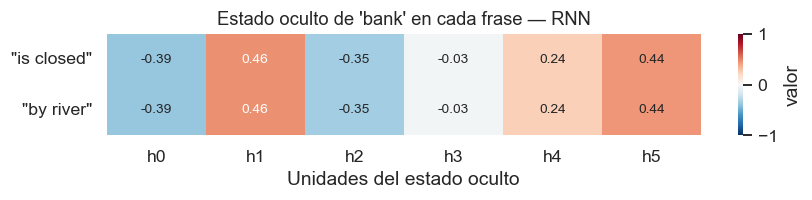

In [3]:
plot_rnn_estados(e1, e2)


<div style="background:#e8f5e9; border-left:4px solid #388e3c; padding:12px 16px; border-radius:6px; margin:6px 0">

**Resultado — RNN:** similitud coseno entre los dos *bank* = **1.000**

La RNN procesa de izquierda a derecha, un token a la vez. Cuando llega a **"bank"** (posición 1), solo ha leído **"the"**. Las dos frases comparten ese prefijo → estados ocultos **idénticos** → la RNN **no puede distinguir** el banco financiero del banco fluvial.

</div>

---
## 👁️ Bloque 2 — Mecanismo de Atención

En lugar de comprimir toda la frase en un solo vector, la atención permite que **cada token vea el contexto de todos los demás** directamente:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right)V$$

| Matriz | Significado |
|--------|-------------|
| **Q** (Query) | ¿qué busca este token? |
| **K** (Key) | ¿qué ofrece cada token? |
| **V** (Value) | ¿qué información devuelve si lo seleccionan? |

El resultado es una **suma ponderada** de todos los *values* — cada token puede atender a cualquier otro, en ambas direcciones.


<div style="background:#fff9c4; border-left:4px solid #f9a825; padding:12px 16px; border-radius:6px; margin:6px 0">

**🤔 Pausa y predice — Atención**

El mecanismo de atención ve *todos* los tokens a la vez, en ambas direcciones. ¿A qué token crees que prestará más atención *"banco"* (posición 2)?

<details><summary>💡 Ver respuesta</summary>

Con pesos **aleatorios** (sin entrenar), la distribución será aproximadamente uniforme — *"banco"* repartirá su atención entre todos los tokens sin un patrón claro.

Pero aquí está la clave: ahora la representación de *"banco"* **sí depende del contexto completo** (incluyendo lo que viene después). Con entrenamiento, aprendería a pesar más *"cerrado"* o *"junto al río"* para desambiguar — eso es precisamente lo que hace BERT.

</details>

</div>

In [4]:
torch.manual_seed(42)
FRASE_ATN  = ["the", "bank", "is", "closed"]
FRASE_ATN2 = ["the", "bank", "by", "river"]
IDX_BANK   = FRASE_ATN.index("bank")
d_attn     = 8
X1 = torch.randn(len(FRASE_ATN), d_attn)
X2 = torch.randn(len(FRASE_ATN2), d_attn)

torch.manual_seed(41)
Wq = torch.randn(d_attn, d_attn)
Wk = torch.randn(d_attn, d_attn)
Wv = torch.randn(d_attn, d_attn)

def calcular_atencion(X, Wq, Wk, Wv, d):
    Q = X @ Wq; K = X @ Wk; V = X @ Wv
    p = torch.softmax(Q @ K.T / (d**0.5), dim=-1)
    return p, p @ V

# Attention(Q, K, V) = softmax( Q·Kᵀ / √d ) · V
Q = X1 @ Wq;  K = X1 @ Wk;  V = X1 @ Wv
scores  = Q @ K.T / (d_attn ** 0.5)
pesos1  = torch.softmax(scores, dim=-1)
output1 = pesos1 @ V

pesos2, output2 = calcular_atencion(X2, Wq, Wk, Wv, d_attn)
pesos_np  = pesos1.numpy()
pesos_bank = {t: round(float(v), 2) for t, v in zip(FRASE_ATN, pesos_np[IDX_BANK])}


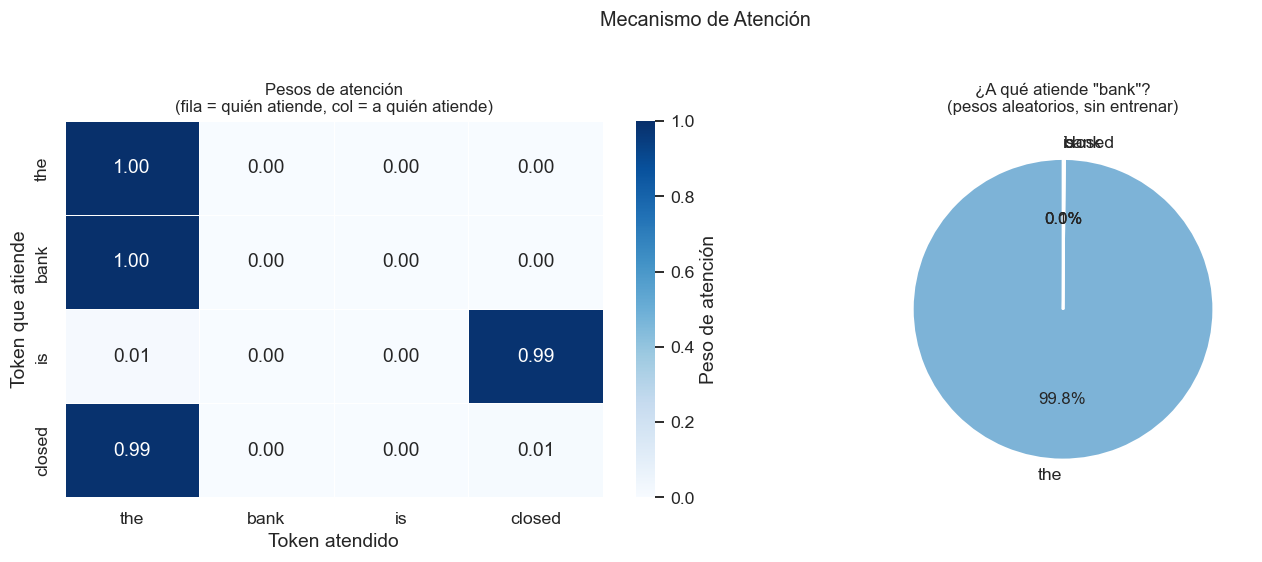

In [5]:
plot_atencion(pesos_np, FRASE_ATN)


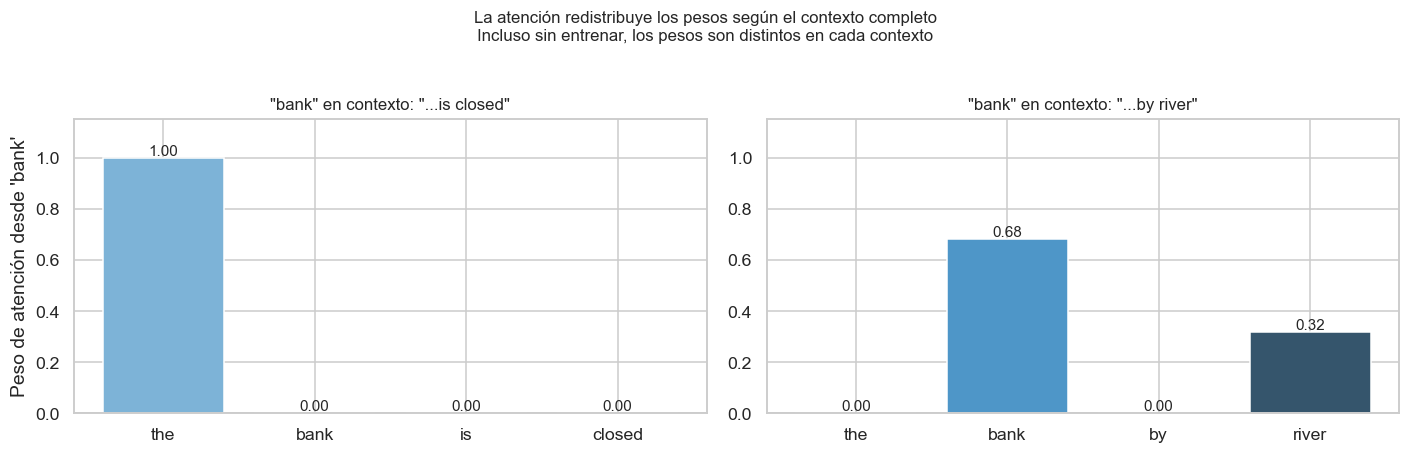

In [6]:
plot_comparacion_attn_contextos(
    pesos1.numpy(), pesos2.numpy(), FRASE_ATN, FRASE_ATN2
)


<div style="background:#e8f5e9; border-left:4px solid #388e3c; padding:12px 16px; border-radius:6px; margin:6px 0">

**Resultado — Atención:** los pesos de *bank* son **casi uniformes** (pesos aleatorios, sin entrenar).

La clave no es el valor de los pesos, sino la **estructura**: la atención puede ver todos los tokens a la vez — incluyendo los que vienen después. Eso es bidireccionalidad por construcción. BERT entrenará con millones de frases y aprenderá a enfocar estos pesos según el significado del contexto.

</div>

---
## 🏗️ Bloque 3 — Del Transformer a BERT y GPT

El Transformer apila capas de atención multicabeza + feed-forward + normalización. La arquitectura es la misma en BERT y GPT — la diferencia es solo de **escala** y de **cómo se pre-entrena**:

| | **BERT** | **GPT** |
|-|----------|---------|
| Atención | Bidireccional (ve izq. y der.) | Causal (solo izquierda) |
| Pre-entrenamiento | Predice tokens enmascarados | Predice el siguiente token |
| Mejor para | Clasificación, NER, QA | Generación de texto |

Entrenar desde cero requiere millones de ejemplos y miles de horas de GPU. La solución: usar modelos **pre-entrenados en texto masivo** y aplicarlos directamente.


In [7]:
torch.manual_seed(0)
d_model = 16
encoder = TransformerEncoderMinimo(d_model=d_model, n_heads=2)
x_enc   = torch.randn(1, 5, d_model)
salida, pesos_enc = encoder(x_enc)

total_params = sum(p.numel() for p in encoder.parameters())
rnn_p  = sum(p.numel() for p in nn.RNN(7, 4).parameters())


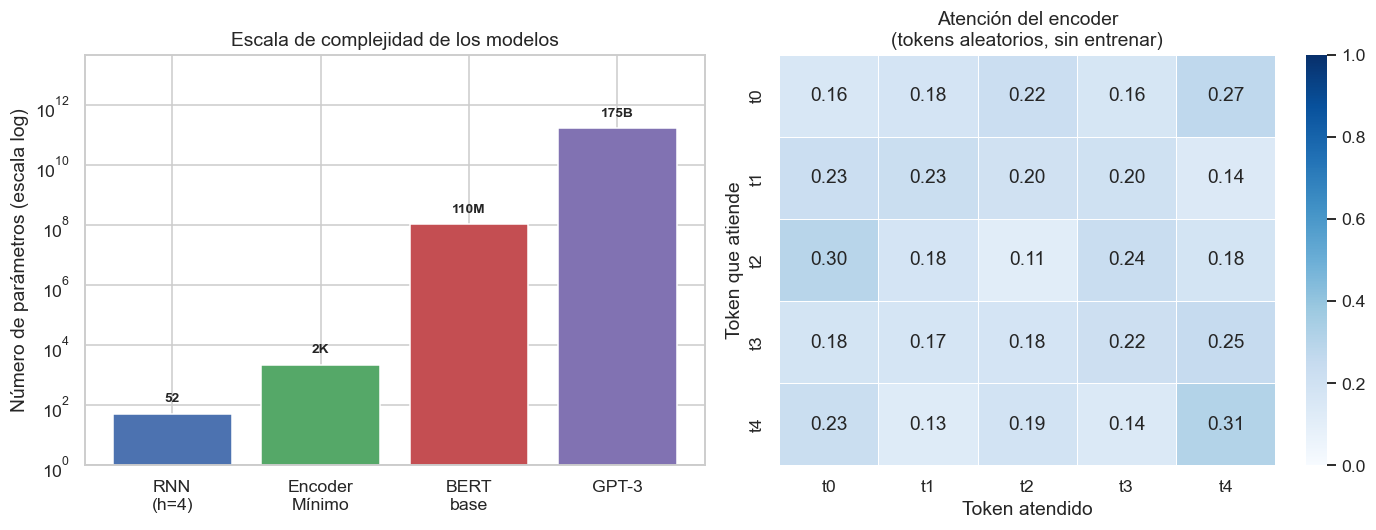

In [8]:
plot_transformer(rnn_p, total_params, pesos_enc)


<div style="background:#fff9c4; border-left:4px solid #f9a825; padding:12px 16px; border-radius:6px; margin:6px 0">

**🤔 Pausa y predice — BERT**

Ahora usamos BERT real, entrenado en millones de textos. ¿Crees que producirá el mismo vector para *"bank"* en estas dos frases?

- *"I went to the **bank** to withdraw money"*
- *"I sat on the **bank** of the river"*

<details><summary>💡 Ver respuesta</summary>

**No.** BERT es **bidireccional**: para generar el embedding de *"bank"*, atiende a todas las palabras de la frase — tanto las previas como las siguientes. En un caso ve *"withdraw money"*; en el otro, *"river"*. La representación final captura esa diferencia.

La similitud coseno será claramente menor que 1.0 — los dos vectores son distintos. Los valores típicos con BERT-base están entre 0.45 y 0.80 dependiendo de cuán diferentes sean los contextos.

</details>

</div>

In [9]:
tokenizer_bert = BertTokenizer.from_pretrained("bert-base-uncased")
model_bert     = BertModel.from_pretrained("bert-base-uncased")
model_bert.eval();


In [10]:
frases_banco = [
    "I went to the bank to withdraw money",
    "I sat on the bank of the river",
]
embs_banco = []
with torch.no_grad():
    for frase in frases_banco:
        inputs   = tokenizer_bert(frase, return_tensors="pt")
        out      = model_bert(**inputs)
        ids      = inputs["input_ids"][0]
        words    = tokenizer_bert.convert_ids_to_tokens(ids)
        embs_banco.append(out.last_hidden_state[0, words.index("bank")].numpy())

sim = np.dot(embs_banco[0], embs_banco[1]) / (
    np.linalg.norm(embs_banco[0]) * np.linalg.norm(embs_banco[1]))
print(f"Similitud coseno entre los dos 'bank': {sim:.3f}")
print("(1.0 = idénticos  ·  cuanto menor, más distingue el contexto)")


Similitud coseno entre los dos 'bank': 0.476
(1.0 = idénticos  ·  cuanto menor, más distingue el contexto)


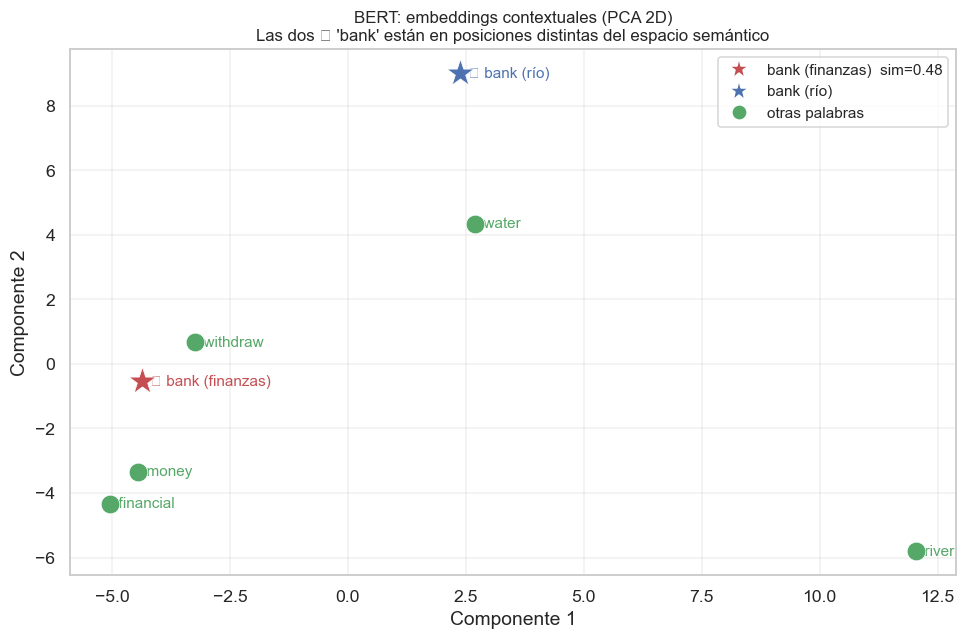

In [11]:
# Añadimos palabras de contexto para enriquecer la visualización PCA
extras = [
    ("money",     "I have a lot of money in my wallet"),
    ("river",     "The river flows through the valley"),
    ("withdraw",  "I need to withdraw cash from the ATM"),
    ("water",     "The water is cold and clear"),
    ("financial", "The financial market crashed yesterday"),
]

todos_embs   = list(embs_banco)
todas_labels = ["\u2605 bank\n(finanzas)", "\u2605 bank\n(río)"]
todos_grupos = [0, 1]

with torch.no_grad():
    for palabra, frase in extras:
        inputs = tokenizer_bert(frase, return_tensors="pt")
        out    = model_bert(**inputs)
        ids    = inputs["input_ids"][0]
        words  = tokenizer_bert.convert_ids_to_tokens(ids)
        if palabra in words:
            emb = out.last_hidden_state[0, words.index(palabra)].numpy()
            todos_embs.append(emb)
            todas_labels.append(palabra)
            todos_grupos.append(2)

plot_bert_pca(todos_embs, todas_labels, todos_grupos, sim)

### 🤖 GPT-2 — generación autorregresiva

GPT lee de izquierda a derecha y predice el siguiente token en cada paso. Sin saber qué significa *bank*, su contexto lo lleva a completar cada frase de forma coherente:


In [12]:
tokenizer_gpt = GPT2Tokenizer.from_pretrained("gpt2")
model_gpt     = GPT2LMHeadModel.from_pretrained("gpt2")
model_gpt.eval();


In [13]:
for prompt in ["I went to the bank to", "I sat on the bank of the"]:
    input_ids = tokenizer_gpt.encode(prompt, return_tensors="pt")
    with torch.no_grad():
        output = model_gpt.generate(
            input_ids, max_new_tokens=8, do_sample=False,
            pad_token_id=tokenizer_gpt.eos_token_id,
        )
    print(f'"{ tokenizer_gpt.decode(output[0], skip_special_tokens=True) }"')


"I went to the bank to get my money back. I was in"
"I sat on the bank of the river, and I saw the great river"


<div style="background:#e8f5e9; border-left:4px solid #388e3c; padding:12px 16px; border-radius:6px; margin:6px 0">

**Resultado — BERT:** las dos apariciones de *bank* ocupan posiciones **distintas** en el espacio semántico (sim = 0.476). El modelo ha aprendido que "withdraw money" y "river" llevan a representaciones separadas.

**GPT-2** confirma la misma intuición desde otro ángulo: completando cada frase de forma coherente con su contexto, aunque nunca haya visto la pregunta "¿cuál es el significado de *bank* aquí?".

</div>

---
## 📊 Resumen — Evolución y por qué importa cada paso

```
  RNN        → procesa en secuencia, un token a la vez
     ↓ problema: unidireccional — al leer "bank" solo ha visto "the"
  Atención   → todos los tokens se relacionan a la vez, en ambas direcciones
     ↓ problema: hay que entrenar desde cero con muchos datos
  Transformer → atención multi-cabeza + capas apiladas + paralelismo total
     ↓ problema: entrenar desde cero es inaccesible (miles a millones de $)
  BERT / GPT → pre-entrenados en texto masivo, listos para usar con pipeline()
     ↓ problema: dominio general, pueden fallar en casos muy específicos
  Fine-tuning → adaptación con tus propios datos   [→ Módulo 6]
```

| Arquitectura | Paralelizable | Contexto global | Necesita pre-entrenamiento |
|:-------------|:-------------:|:---------------:|:--------------------------:|
| RNN          | ❌ | ❌ | ❌ |
| Atención     | ✅ | ✅ | ❌ |
| Transformer  | ✅ | ✅ | ❌ |
| BERT / GPT   | ✅ | ✅ | ✅ ya incluido |

> **Siguiente paso →** Módulo 6: fine-tuning de BERT para tu dominio específico.
